In [1]:
import openslide
import pyvips
import numpy as np

def save_crop(
    mrxs_path: str, 
    output_path: str,
    start_coords: tuple[int, int],  
    region_size: tuple[int, int]
) -> None:
    slide = openslide.OpenSlide(mrxs_path)
    
    start_x, start_y = start_coords
    region_width, region_height = region_size

    print(f"Extracting {region_width}x{region_height} window from Level 0 at {start_x}x{start_y}...")

    crop_pil = slide.read_region(
        (start_x, start_y), 0, (region_width, region_height)
    ).convert("RGB")

    crop_np = np.array(crop_pil)
    height, width, bands = crop_np.shape
    linear = crop_np.reshape(width * height * bands)
    vips_img = pyvips.Image.new_from_memory(linear.data, width, height, bands, "uchar")

    print(f"Saving pyramidal TIFF to {output_path}...")
    vips_img.tiffsave(
        output_path,
        compression=pyvips.enums.ForeignTiffCompression.DEFLATE,
        tile=True,
        tile_width=256,
        tile_height=256,
        pyramid=True,
        bigtiff=True,
    )

    print("Done!")

In [3]:
import tifffile
import numpy as np
from PIL import Image
from IPython.display import display

tiff_path = "/home/jovyan/nuclei-graph-transformer/amacr_mask/input/crop_shadow.tiff"

def show_tiff_pyramid(tiff_path):
    with tifffile.TiffFile(tiff_path) as tif:
        series = tif.series[0]

        print("Available pyramid levels:")
        for i, level in enumerate(series.levels):
            print(f"Level {i}: shape = {level.shape}")

        level_index = 3
        print(f"\nDisplaying level {level_index} (lowest resolution)...")

        arr = series.levels[level_index].asarray()

    if arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)

    img = Image.fromarray(arr)
    display(img)


In [ ]:
mrxs_path = "/mnt/projects/nuclei_based_wsi_analysis/amacr_ground_truth_test/wsi_data/2025_09852-01-02-05-AMACR.mrxs"
crop_shadow_tiff_path = "/home/jovyan/nuclei-graph-transformer/amacr_mask/input/crop_shadow.tiff"

start_x = 22857
start_y = 106165

region_width = 3000
region_height = 3000

In [6]:
save_crop(mrxs_path, crop_shadow_tiff_path, (start_x, start_y), (region_width, region_height))

Extracting 3000x3000 window from Level 0 at 22857x106165...
Saving pyramidal TIFF to /home/jovyan/nuclei-graph-transformer/amacr_mask/input/crop_shadow.tiff...
Done!


Available pyramid levels:
Level 0: shape = (3000, 3000, 3)
Level 1: shape = (1500, 1500, 3)
Level 2: shape = (750, 750, 3)
Level 3: shape = (375, 375, 3)
Level 4: shape = (187, 187, 3)

Displaying level 3 (lowest resolution)...


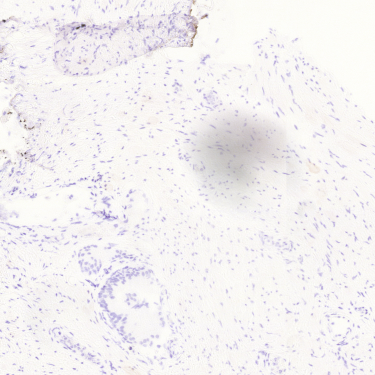

In [7]:
show_tiff_pyramid(crop_shadow_tiff_path)

Available pyramid levels:
Level 0: shape = (3000, 3000, 4)
Level 1: shape = (1500, 1500, 4)
Level 2: shape = (750, 750, 4)
Level 3: shape = (375, 375, 4)
Level 4: shape = (187, 187, 4)

Displaying level 3 (lowest resolution)...


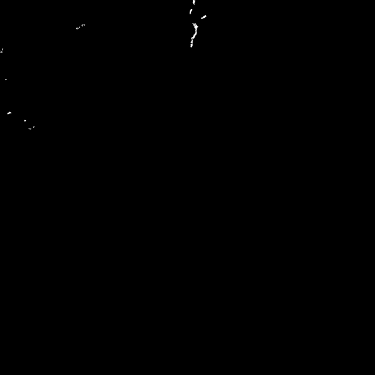

In [11]:
processed_crop_path = "/home/jovyan/nuclei-graph-transformer/amacr_mask/mask/crop_shadow.tif"
show_tiff_pyramid(processed_crop_path)

Available pyramid levels:
Level 0: shape = (3000, 3000, 4)
Level 1: shape = (1500, 1500, 4)
Level 2: shape = (750, 750, 4)
Level 3: shape = (375, 375, 4)
Level 4: shape = (187, 187, 4)

Displaying level 3 (lowest resolution)...


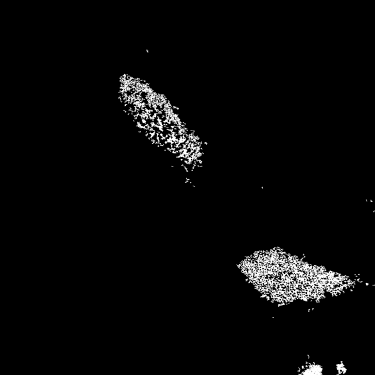

In [10]:
processed_crop_path = "/home/jovyan/nuclei-graph-transformer/amacr_mask/mask/crop_pyramid.tif"
show_tiff_pyramid(processed_crop_path)